In [3]:
from __future__ import annotations

import sys
from pathlib import Path

# The notebook is stored in HWI/notebooks, so its parent is the project root.
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(
        f"Could not detect the project root from: {Path.cwd()}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Current working directory: {Path.cwd()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"src exists: {(PROJECT_ROOT / 'src').exists()}")

Current working directory: C:\DBS\Sem 2\Aplied Research\HWI\notebooks
Project root: C:\DBS\Sem 2\Aplied Research\HWI
src exists: True


In [4]:
import json

import pandas as pd
from IPython.display import Image, Markdown, display

from src.config import (
    EDA_FIGURES_DIR,
    EDA_REPORTS_DIR,
    EDA_STATISTICS_DIR,
    RAW_DATA_DIR,
)

print("Imports completed successfully.")

Imports completed successfully.


In [5]:
awareness_dataset_path = (
    RAW_DATA_DIR
    / "awareness"
    / "phishing_awareness_dataset.csv"
)

awareness_column_profile_path = (
    EDA_REPORTS_DIR
    / "awareness_phishing_awareness_dataset_column_profile.csv"
)

awareness_summary_path = (
    EDA_REPORTS_DIR
    / "awareness_phishing_awareness_dataset_eda_summary.json"
)

awareness_numeric_summary_path = (
    EDA_STATISTICS_DIR
    / "awareness_phishing_awareness_dataset_numeric_summary.csv"
)

awareness_categorical_summary_path = (
    EDA_STATISTICS_DIR
    / "awareness_phishing_awareness_dataset_categorical_summary.csv"
)

awareness_correlation_path = (
    EDA_STATISTICS_DIR
    / "awareness_phishing_awareness_dataset_pearson_correlation.csv"
)

paths_to_check = {
    "raw dataset": awareness_dataset_path,
    "column profile": awareness_column_profile_path,
    "EDA summary": awareness_summary_path,
    "numeric summary": awareness_numeric_summary_path,
    "categorical summary": awareness_categorical_summary_path,
    "correlation": awareness_correlation_path,
}

for name, path in paths_to_check.items():
    print(f"{name}: {path.exists()} — {path}")

raw dataset: True — C:\DBS\Sem 2\Aplied Research\HWI\data\raw\awareness\phishing_awareness_dataset.csv
column profile: True — C:\DBS\Sem 2\Aplied Research\HWI\outputs\reports\eda\awareness_phishing_awareness_dataset_column_profile.csv
EDA summary: True — C:\DBS\Sem 2\Aplied Research\HWI\outputs\reports\eda\awareness_phishing_awareness_dataset_eda_summary.json
numeric summary: True — C:\DBS\Sem 2\Aplied Research\HWI\outputs\statistics\eda\awareness_phishing_awareness_dataset_numeric_summary.csv
categorical summary: True — C:\DBS\Sem 2\Aplied Research\HWI\outputs\statistics\eda\awareness_phishing_awareness_dataset_categorical_summary.csv
correlation: True — C:\DBS\Sem 2\Aplied Research\HWI\outputs\statistics\eda\awareness_phishing_awareness_dataset_pearson_correlation.csv


In [6]:
awareness_df = pd.read_csv(
    awareness_dataset_path,
    low_memory=False,
)

print(f"Rows: {awareness_df.shape[0]:,}")
print(f"Columns: {awareness_df.shape[1]:,}")

display(awareness_df.head(10))

Rows: 5,000
Columns: 12


,user_id,email_subject,sender_email_domain,hover_time_ms,clicked_link,reported_email,device_type,browser_used,email_received_time,session_duration_sec,geo_location,email_language
0,5855edec-216a-4fdd-9f3b-14d83fef657e,Hospital cause simply.,leonard.com,3139,no,no,mobile,Edge,2025-02-19T19:48:02,264,"48.9992835,12.888175",French
1,494e756a-9b8e-4da1-bd16-5906fa846395,Play identify Democrat director.,bridges-smith.org,934,yes,yes,desktop,Edge,2025-01-28T14:30:40,263,"59.0786685,-93.727570",English
2,72d18c59-da69-4995-b03b-7d43bb094443,Compare population happen tree our.,morris-hanson.com,2367,yes,no,desktop,Safari,2025-01-05T19:35:17,227,"-41.6574815,-17.439238",Japanese
3,bd92dd2f-cbd9-4481-9276-e7108c0bafdb,Continue smile back successful.,rowe-ibarra.com,6876,yes,yes,desktop,Firefox,2025-03-23T02:45:45,214,"-86.8348325,-139.476991",German
4,146ce2ee-2e6e-4963-9b37-4ae09aa2dc2a,Collection individual entire official bar work...,hampton.biz,2868,yes,no,desktop,Chrome,2025-02-05T23:31:42,570,"52.047245,83.387666",Spanish
5,047d7b29-2aa7-4319-a278-5aaf34ba2efa,Small market majority agree more whom attack.,anderson.com,2719,yes,no,mobile,Chrome,2025-02-10T17:12:29,409,"28.165231,-59.510344",English
6,42f39707-1682-4d35-a481-cf8d79e50b6d,Recently mind pattern to land national.,patel.com,2062,yes,no,mobile,Safari,2025-02-04T08:45:13,29,"18.9581145,-85.742699",Japanese
7,b2d1c1ad-fa2b-4fd5-8611-2f673db88ed5,Pretty instead growth field rule cup student.,farmer-graham.com,9722,yes,no,mobile,Opera,2025-02-11T02:52:50,49,"-34.3698705,109.344671",German
8,034f810a-d5c2-4710-aaf0-1cdb00834982,Certain specific support trade determine likely.,pratt.com,2535,no,yes,desktop,Firefox,2025-01-04T14:15:11,323,"-52.037061,-61.751515",French
9,f9422237-ec9b-43d6-b442-e45a2af26be5,Base often all election forget.,mcdaniel.com,3827,no,no,mobile,Safari,2025-03-17T06:20:57,552,"20.102364,45.721218",French


In [7]:
structure_table = pd.DataFrame(
    {
        "column": awareness_df.columns,
        "dtype": awareness_df.dtypes.astype(str).values,
        "missing_count": awareness_df.isna().sum().values,
        "missing_percentage": (
            awareness_df.isna().mean().mul(100).round(2).values
        ),
        "unique_count": awareness_df.nunique(dropna=True).values,
    }
)

display(structure_table)

,column,dtype,missing_count,missing_percentage,unique_count
0,user_id,str,0,0.0,5000
1,email_subject,str,0,0.0,5000
2,sender_email_domain,str,0,0.0,3316
3,hover_time_ms,int64,0,0.0,3869
4,clicked_link,str,0,0.0,2
5,reported_email,str,0,0.0,2
6,device_type,str,0,0.0,2
7,browser_used,str,0,0.0,5
8,email_received_time,str,0,0.0,5000
9,session_duration_sec,int64,0,0.0,590


In [8]:
column_profile = pd.read_csv(
    awareness_column_profile_path
)

numeric_summary = pd.read_csv(
    awareness_numeric_summary_path
)

categorical_summary = pd.read_csv(
    awareness_categorical_summary_path
)

if awareness_correlation_path.exists():
    correlation_summary = pd.read_csv(
        awareness_correlation_path,
        index_col=0,
    )
else:
    correlation_summary = pd.DataFrame()

with awareness_summary_path.open(
    "r",
    encoding="utf-8",
) as file:
    eda_summary = json.load(file)

print("All awareness EDA reports loaded successfully.")

All awareness EDA reports loaded successfully.


In [9]:
display(column_profile)

,column,dtype,rows_analysed,non_null_count,missing_count,missing_percentage,unique_count,uniqueness_percentage,average_string_length,minimum_value,maximum_value,sample_values
0,user_id,str,5000,5000,0,0.0,5000,100.00,36.000,001c72b0-503a-44d2-87f2-7232ae1ca889,ffff6aa1-de53-437d-a833-83cea47e72a3,5855edec-216a-4fdd-9f3b-14d83fef657e | 494e756...
1,email_subject,str,5000,5000,0,0.0,5000,100.00,36.013,A often door city morning.,Yourself what perhaps add minute because.,Hospital cause simply. | Play identify Democra...
2,sender_email_domain,str,5000,5000,0,0.0,3316,66.32,12.511,abbott-mayer.com,zuniga-dean.net,leonard.com | bridges-smith.org | morris-hanso...
3,hover_time_ms,int64,5000,5000,0,0.0,3869,77.38,NaN,500,10000,3139 | 934 | 2367 | 6876 | 2868
4,clicked_link,str,5000,5000,0,0.0,2,0.04,2.504,no,yes,no | yes
5,reported_email,str,5000,5000,0,0.0,2,0.04,2.506,no,yes,no | yes
6,device_type,str,5000,5000,0,0.0,2,0.04,6.503,desktop,mobile,mobile | desktop
7,browser_used,str,5000,5000,0,0.0,5,0.10,5.604,Chrome,Safari,Edge | Safari | Firefox | Chrome | Opera
8,email_received_time,str,5000,5000,0,0.0,5000,100.00,19.000,2025-01-01T01:28:40,2025-04-04T07:24:54,2025-02-19T19:48:02 | 2025-01-28T14:30:40 | 20...
9,session_duration_sec,int64,5000,5000,0,0.0,590,11.80,NaN,10,600,264 | 263 | 227 | 214 | 570


In [10]:
display(numeric_summary)

,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_count,missing_percentage,skewness,kurtosis,unique_count,zero_count,infinite_count_original
0,hover_time_ms,5000.0,5264.5784,2757.712478,500.0,583.99,976.0,2836.5,5244.0,7675.75,9538.1,9913.02,10000.0,0,0.0,-0.001548,-1.217720,3869,0,0
1,session_duration_sec,5000.0,307.5200,170.708380,10.0,16.00,40.0,157.0,312.0,456.00,572.0,595.00,600.0,0,0.0,-0.029640,-1.201613,590,0,0


In [11]:
display(categorical_summary)

,column,rank,value,count,percentage
0,clicked_link,1,yes,2521,50.42
1,clicked_link,2,no,2479,49.58
2,reported_email,1,yes,2528,50.56
3,reported_email,2,no,2472,49.44
4,device_type,1,desktop,2515,50.30
5,device_type,2,mobile,2485,49.70
6,browser_used,1,Firefox,1042,20.84
7,browser_used,2,Edge,1016,20.32
8,browser_used,3,Opera,989,19.78
9,browser_used,4,Safari,987,19.74


In [12]:
clicked_link_summary = categorical_summary.loc[
    categorical_summary["column"] == "clicked_link"
].copy()

display(clicked_link_summary)

,column,rank,value,count,percentage
0,clicked_link,1,yes,2521,50.42
1,clicked_link,2,no,2479,49.58


In [13]:
reported_email_summary = categorical_summary.loc[
    categorical_summary["column"] == "reported_email"
].copy()

display(reported_email_summary)

,column,rank,value,count,percentage
2,reported_email,1,yes,2528,50.56
3,reported_email,2,no,2472,49.44


In [14]:
clicked_counts = (
    awareness_df["clicked_link"]
    .value_counts(dropna=False)
    .rename_axis("clicked_link")
    .reset_index(name="count")
)

clicked_counts["percentage"] = (
    clicked_counts["count"]
    .div(len(awareness_df))
    .mul(100)
    .round(2)
)

display(clicked_counts)

,clicked_link,count,percentage
0,yes,2521,50.42
1,no,2479,49.58


In [15]:
reported_counts = (
    awareness_df["reported_email"]
    .value_counts(dropna=False)
    .rename_axis("reported_email")
    .reset_index(name="count")
)

reported_counts["percentage"] = (
    reported_counts["count"]
    .div(len(awareness_df))
    .mul(100)
    .round(2)
)

display(reported_counts)

,reported_email,count,percentage
0,yes,2528,50.56
1,no,2472,49.44


In [16]:
clicked_reported_crosstab = pd.crosstab(
    awareness_df["clicked_link"],
    awareness_df["reported_email"],
    margins=True,
)

display(clicked_reported_crosstab)

reported_email,no,yes,All
clicked_link,,,
no,1201,1278,2479
yes,1271,1250,2521
All,2472,2528,5000


In [17]:
clicked_reported_percentages = (
    pd.crosstab(
        awareness_df["clicked_link"],
        awareness_df["reported_email"],
        normalize="index",
    )
    .mul(100)
    .round(2)
)

display(clicked_reported_percentages)

reported_email,no,yes
clicked_link,,
no,48.45,51.55
yes,50.42,49.58


In [18]:
behaviour_by_click = (
    awareness_df
    .groupby("clicked_link")[
        [
            "hover_time_ms",
            "session_duration_sec",
        ]
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    )
    .round(2)
)

display(behaviour_by_click)

hover_time_ms                                        \
                     count     mean  median      std  min    max   
clicked_link                                                       
no                    2479  5253.85  5206.0  2753.39  503  10000   
yes                   2521  5275.13  5289.0  2762.46  500  10000   

             session_duration_sec                                 
                            count   mean median     std min  max  
clicked_link                                                      
no                           2479  310.8  319.0  171.58  10  600  
yes                          2521  304.3  307.0  169.82  10  600

In [19]:
context_columns = [
    "device_type",
    "browser_used",
    "email_language",
]

for column in context_columns:
    display(
        Markdown(
            f"### Click percentages by `{column}`"
        )
    )

    table = (
        pd.crosstab(
            awareness_df[column],
            awareness_df["clicked_link"],
            normalize="index",
        )
        .mul(100)
        .round(2)
    )

    display(table)

### Click percentages by `device_type`

clicked_link,no,yes
device_type,,
desktop,49.34,50.66
mobile,49.82,50.18


### Click percentages by `browser_used`

clicked_link,no,yes
browser_used,,
Chrome,51.76,48.24
Edge,48.92,51.08
Firefox,50.96,49.04
Opera,49.14,50.86
Safari,47.11,52.89


### Click percentages by `email_language`

clicked_link,no,yes
email_language,,
Chinese,49.56,50.44
English,49.18,50.82
French,49.15,50.85
German,50.66,49.34
Japanese,50.31,49.69
Spanish,48.66,51.34


In [20]:
email_received_datetime = pd.to_datetime(
    awareness_df["email_received_time"],
    errors="coerce",
)

print(
    "Invalid timestamps:",
    email_received_datetime.isna().sum(),
)
print(
    "Earliest timestamp:",
    email_received_datetime.min(),
)
print(
    "Latest timestamp:",
    email_received_datetime.max(),
)

Invalid timestamps: 0
Earliest timestamp: 2025-01-01 01:28:40
Latest timestamp: 2025-04-04 07:24:54


In [21]:
time_eda = pd.DataFrame(
    {
        "hour": email_received_datetime.dt.hour,
        "day_of_week": email_received_datetime.dt.day_name(),
        "clicked_link": awareness_df["clicked_link"],
    }
)

display(time_eda.head())

,hour,day_of_week,clicked_link
0,19,Wednesday,no
1,14,Tuesday,yes
2,19,Sunday,yes
3,2,Sunday,yes
4,23,Wednesday,yes


In [22]:
if correlation_summary.empty:
    print(
        "No correlation report was generated because fewer "
        "than two usable numeric columns were available."
    )
else:
    display(correlation_summary)

,hover_time_ms,session_duration_sec
hover_time_ms,1.000000,-0.025059
session_duration_sec,-0.025059,1.000000


Figures found: 7


### Awareness Phishing Awareness Dataset Browser Used Categories

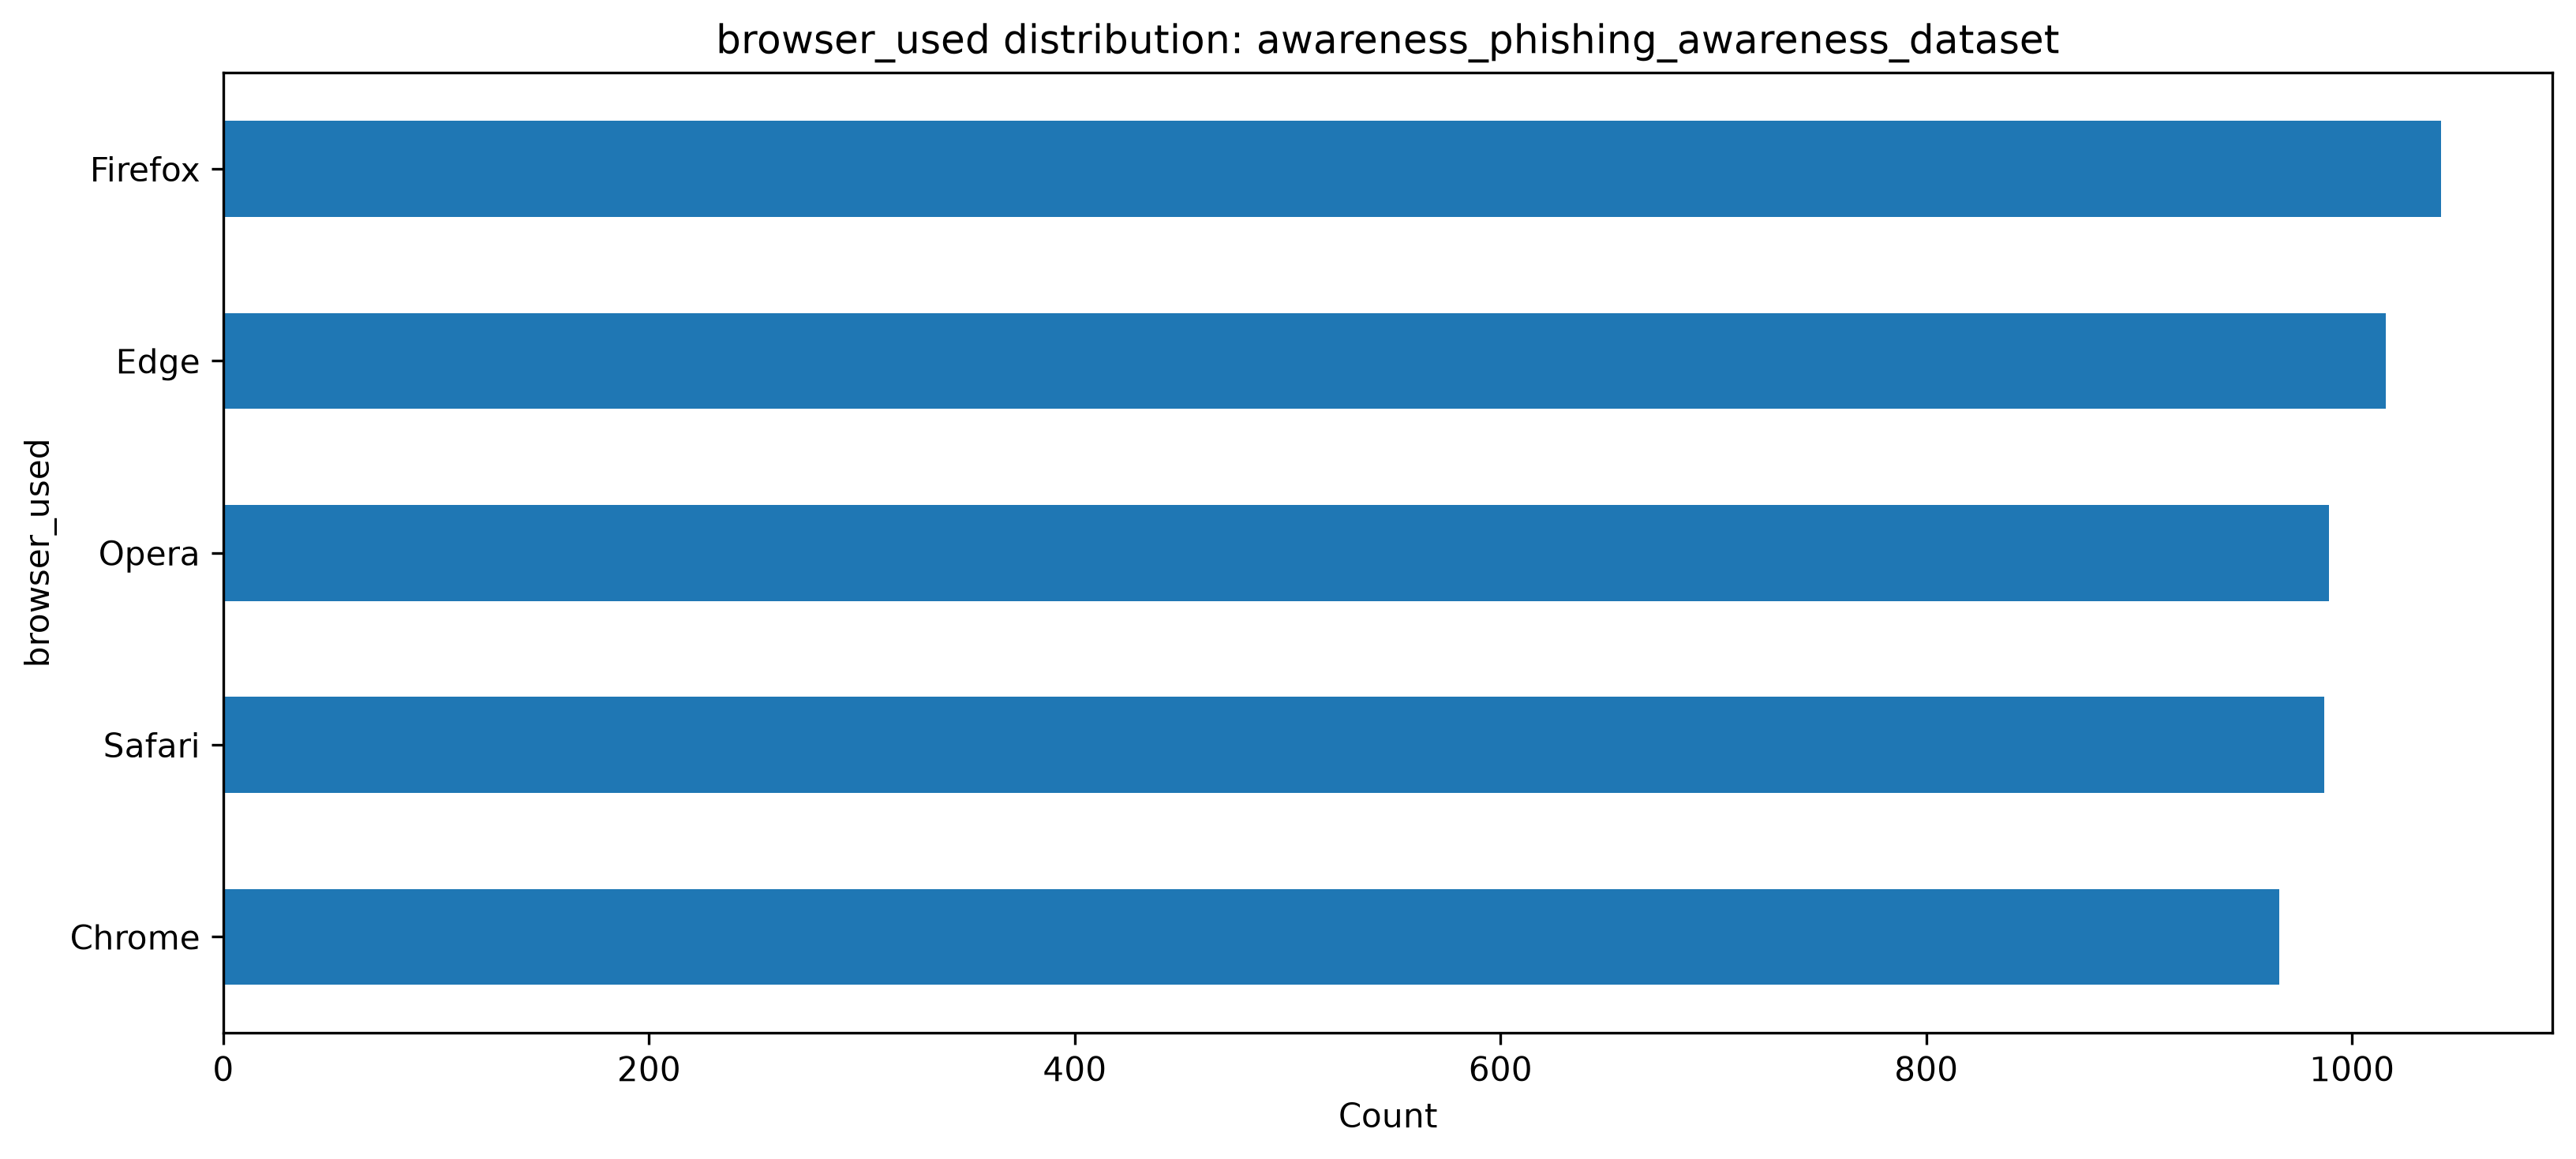

### Awareness Phishing Awareness Dataset Clicked Link Categories

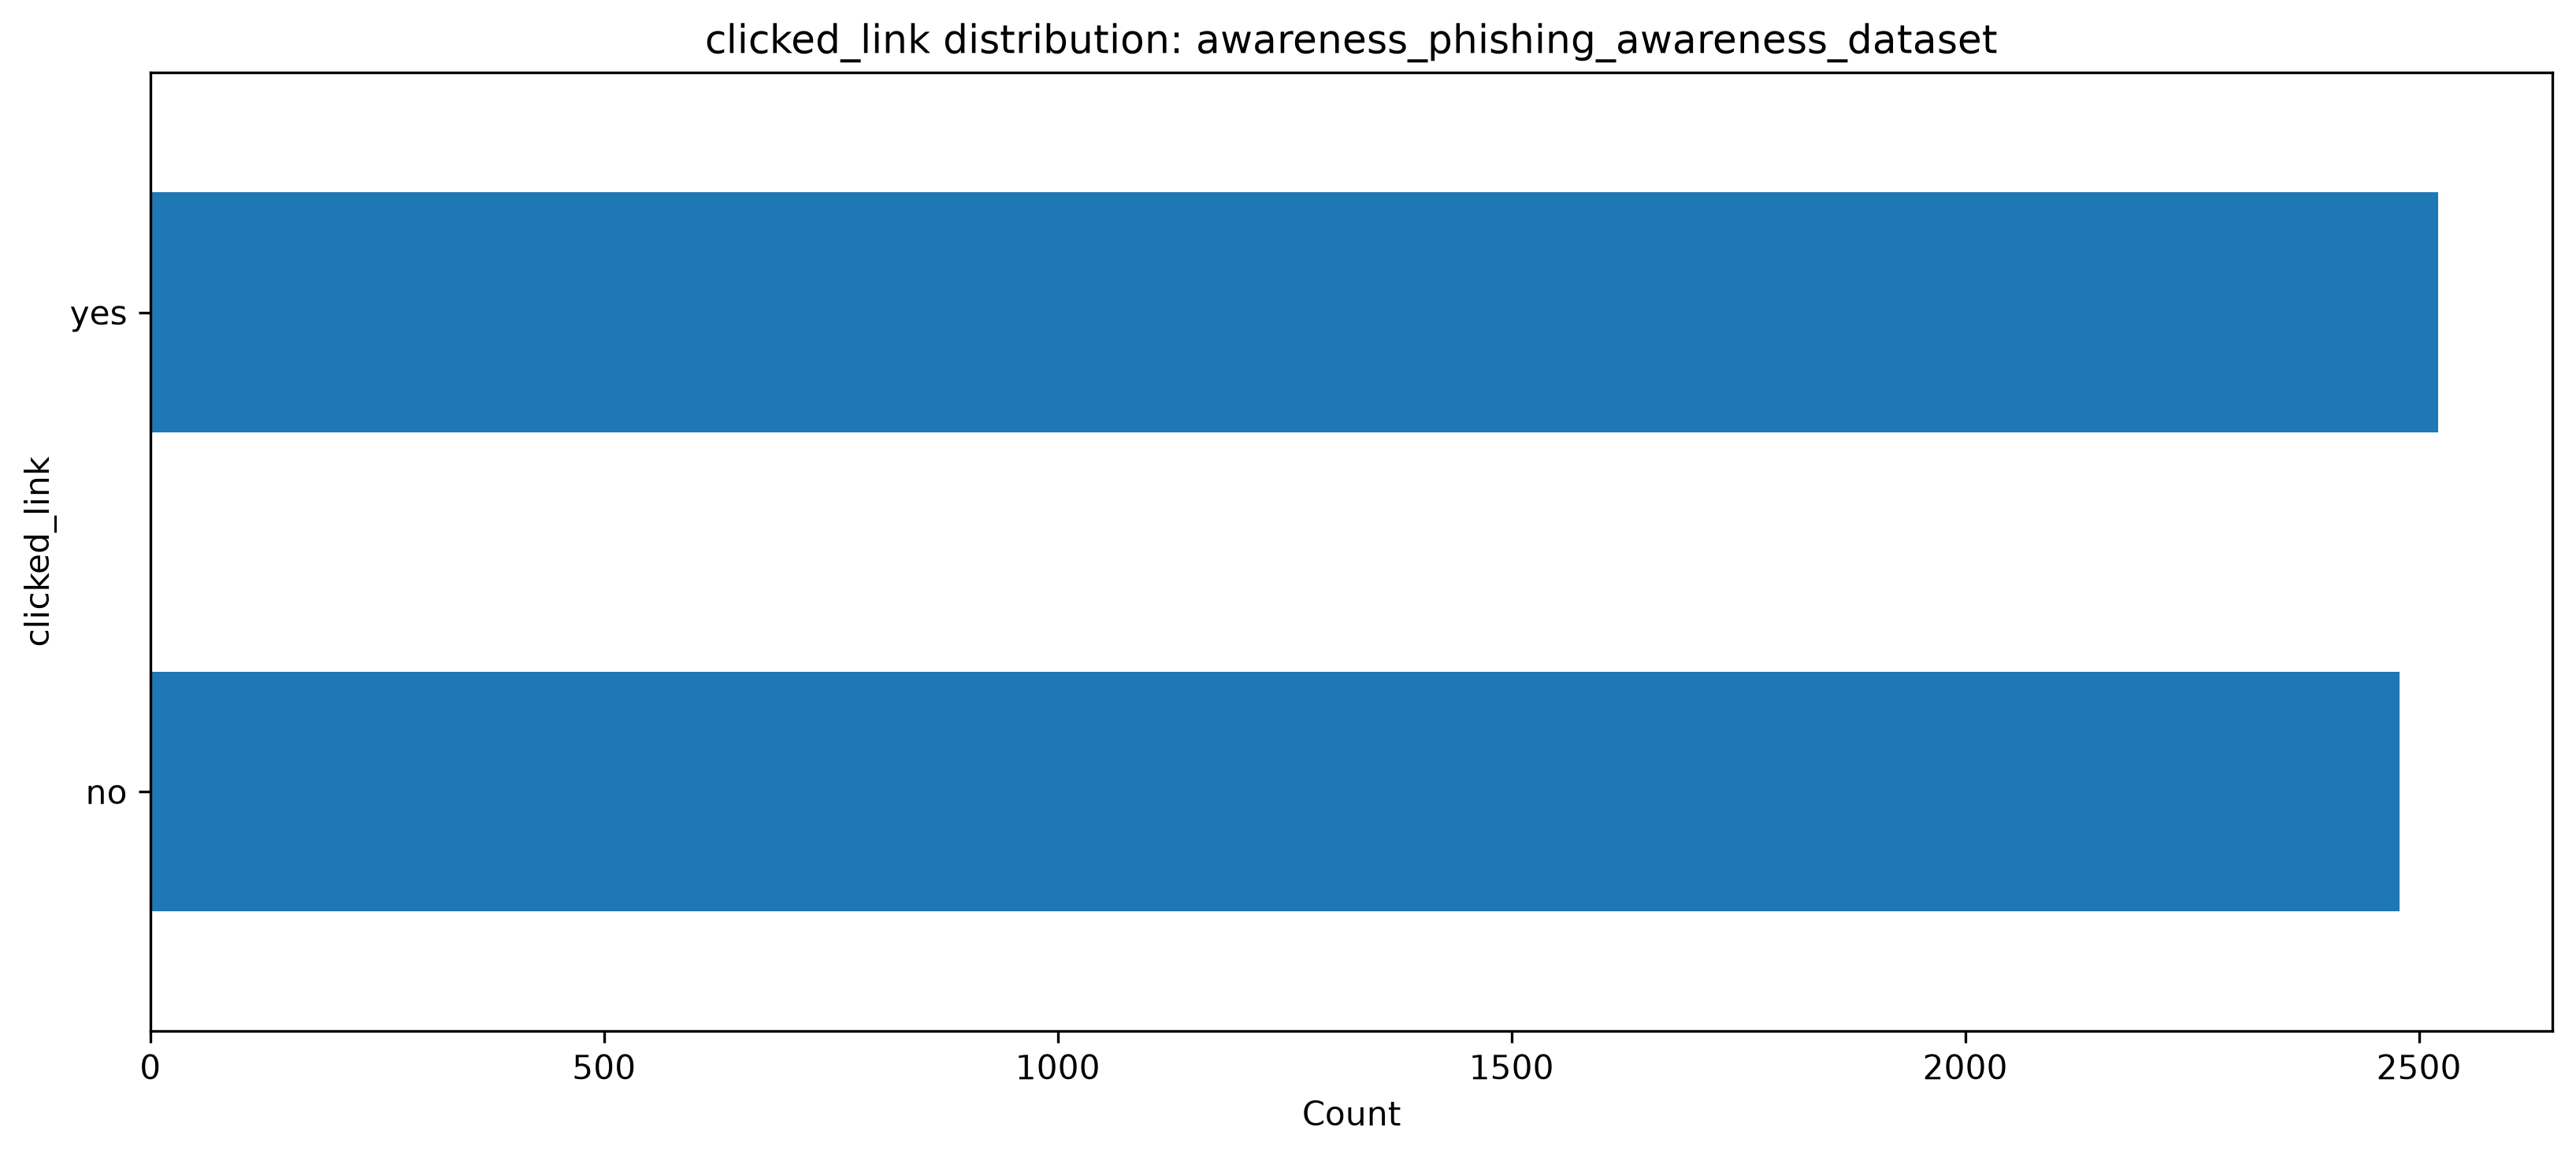

### Awareness Phishing Awareness Dataset Device Type Categories

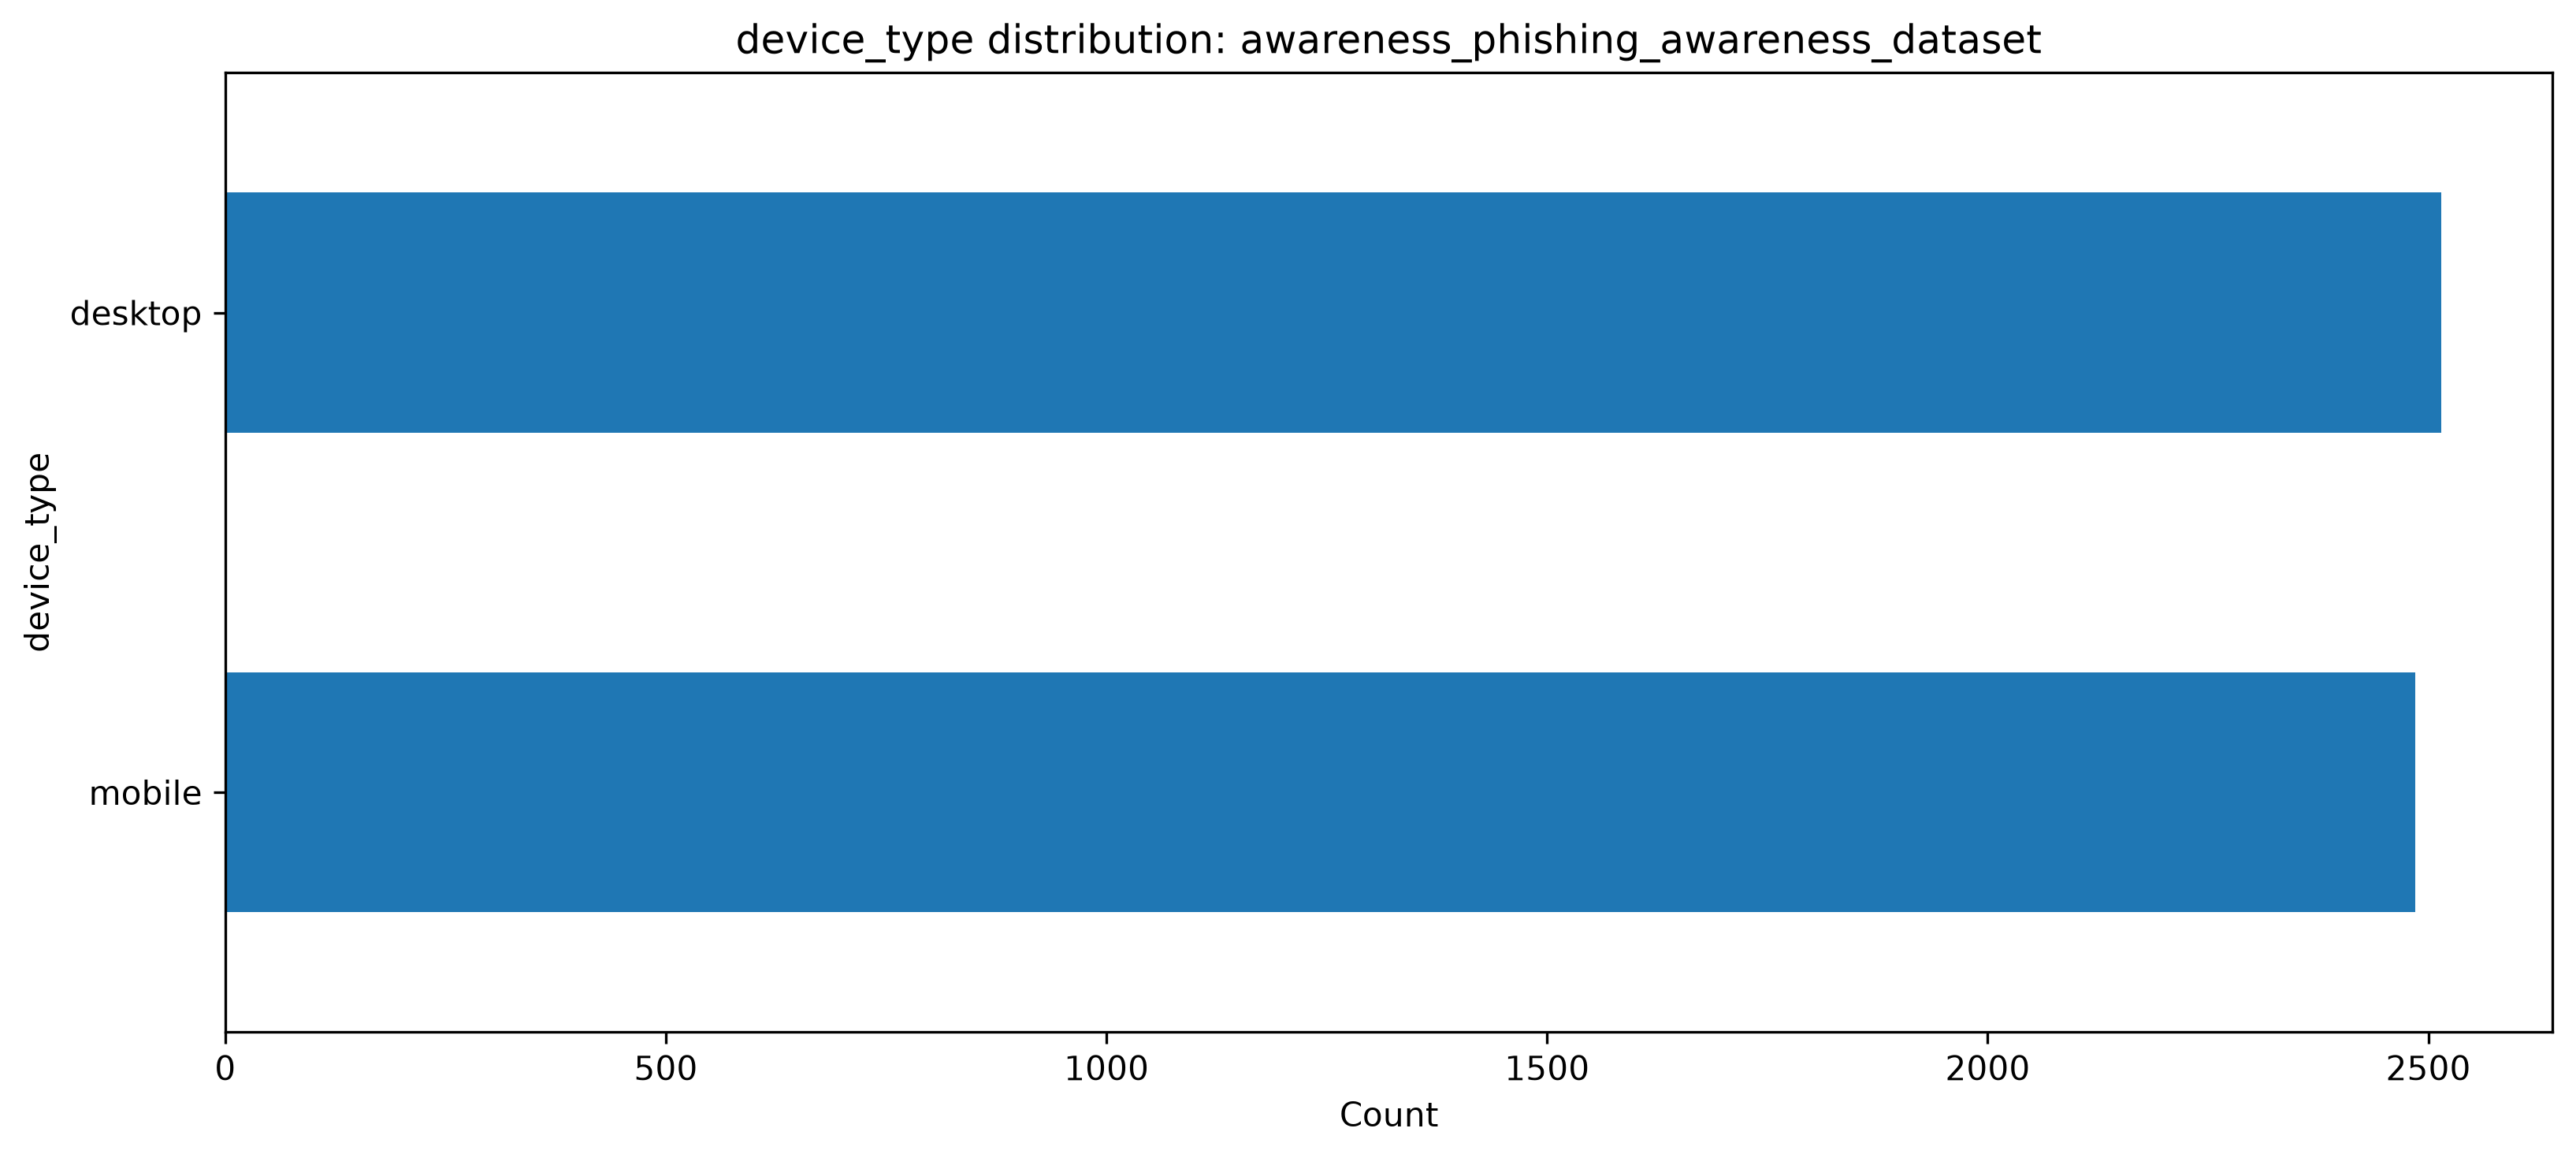

### Awareness Phishing Awareness Dataset Email Language Categories

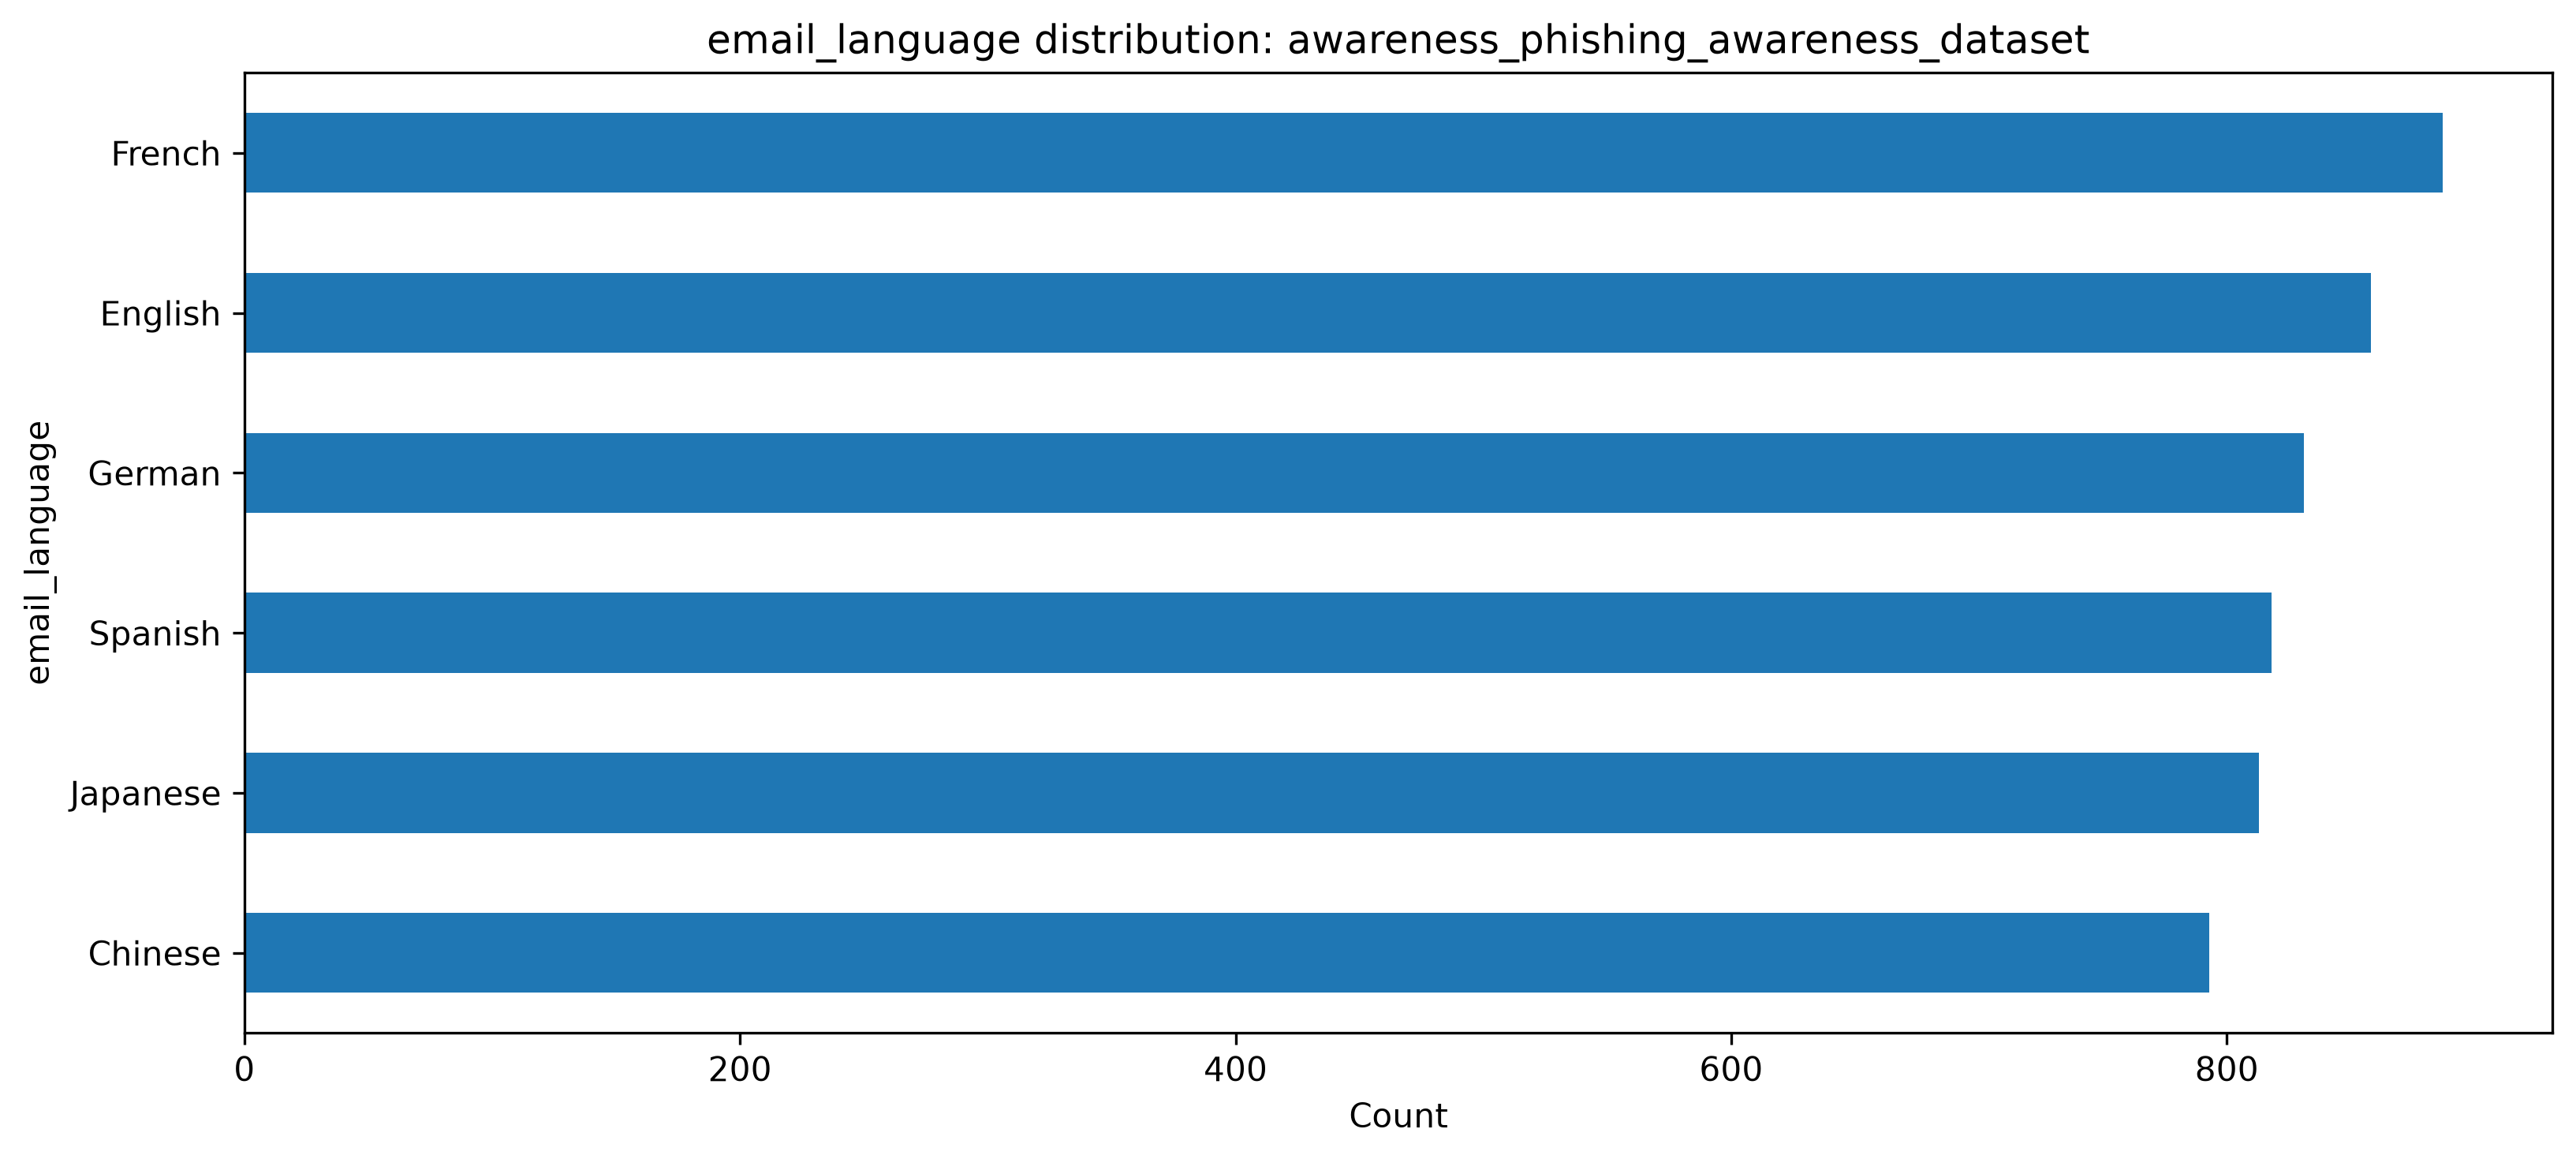

### Awareness Phishing Awareness Dataset Hover Time Ms Histogram

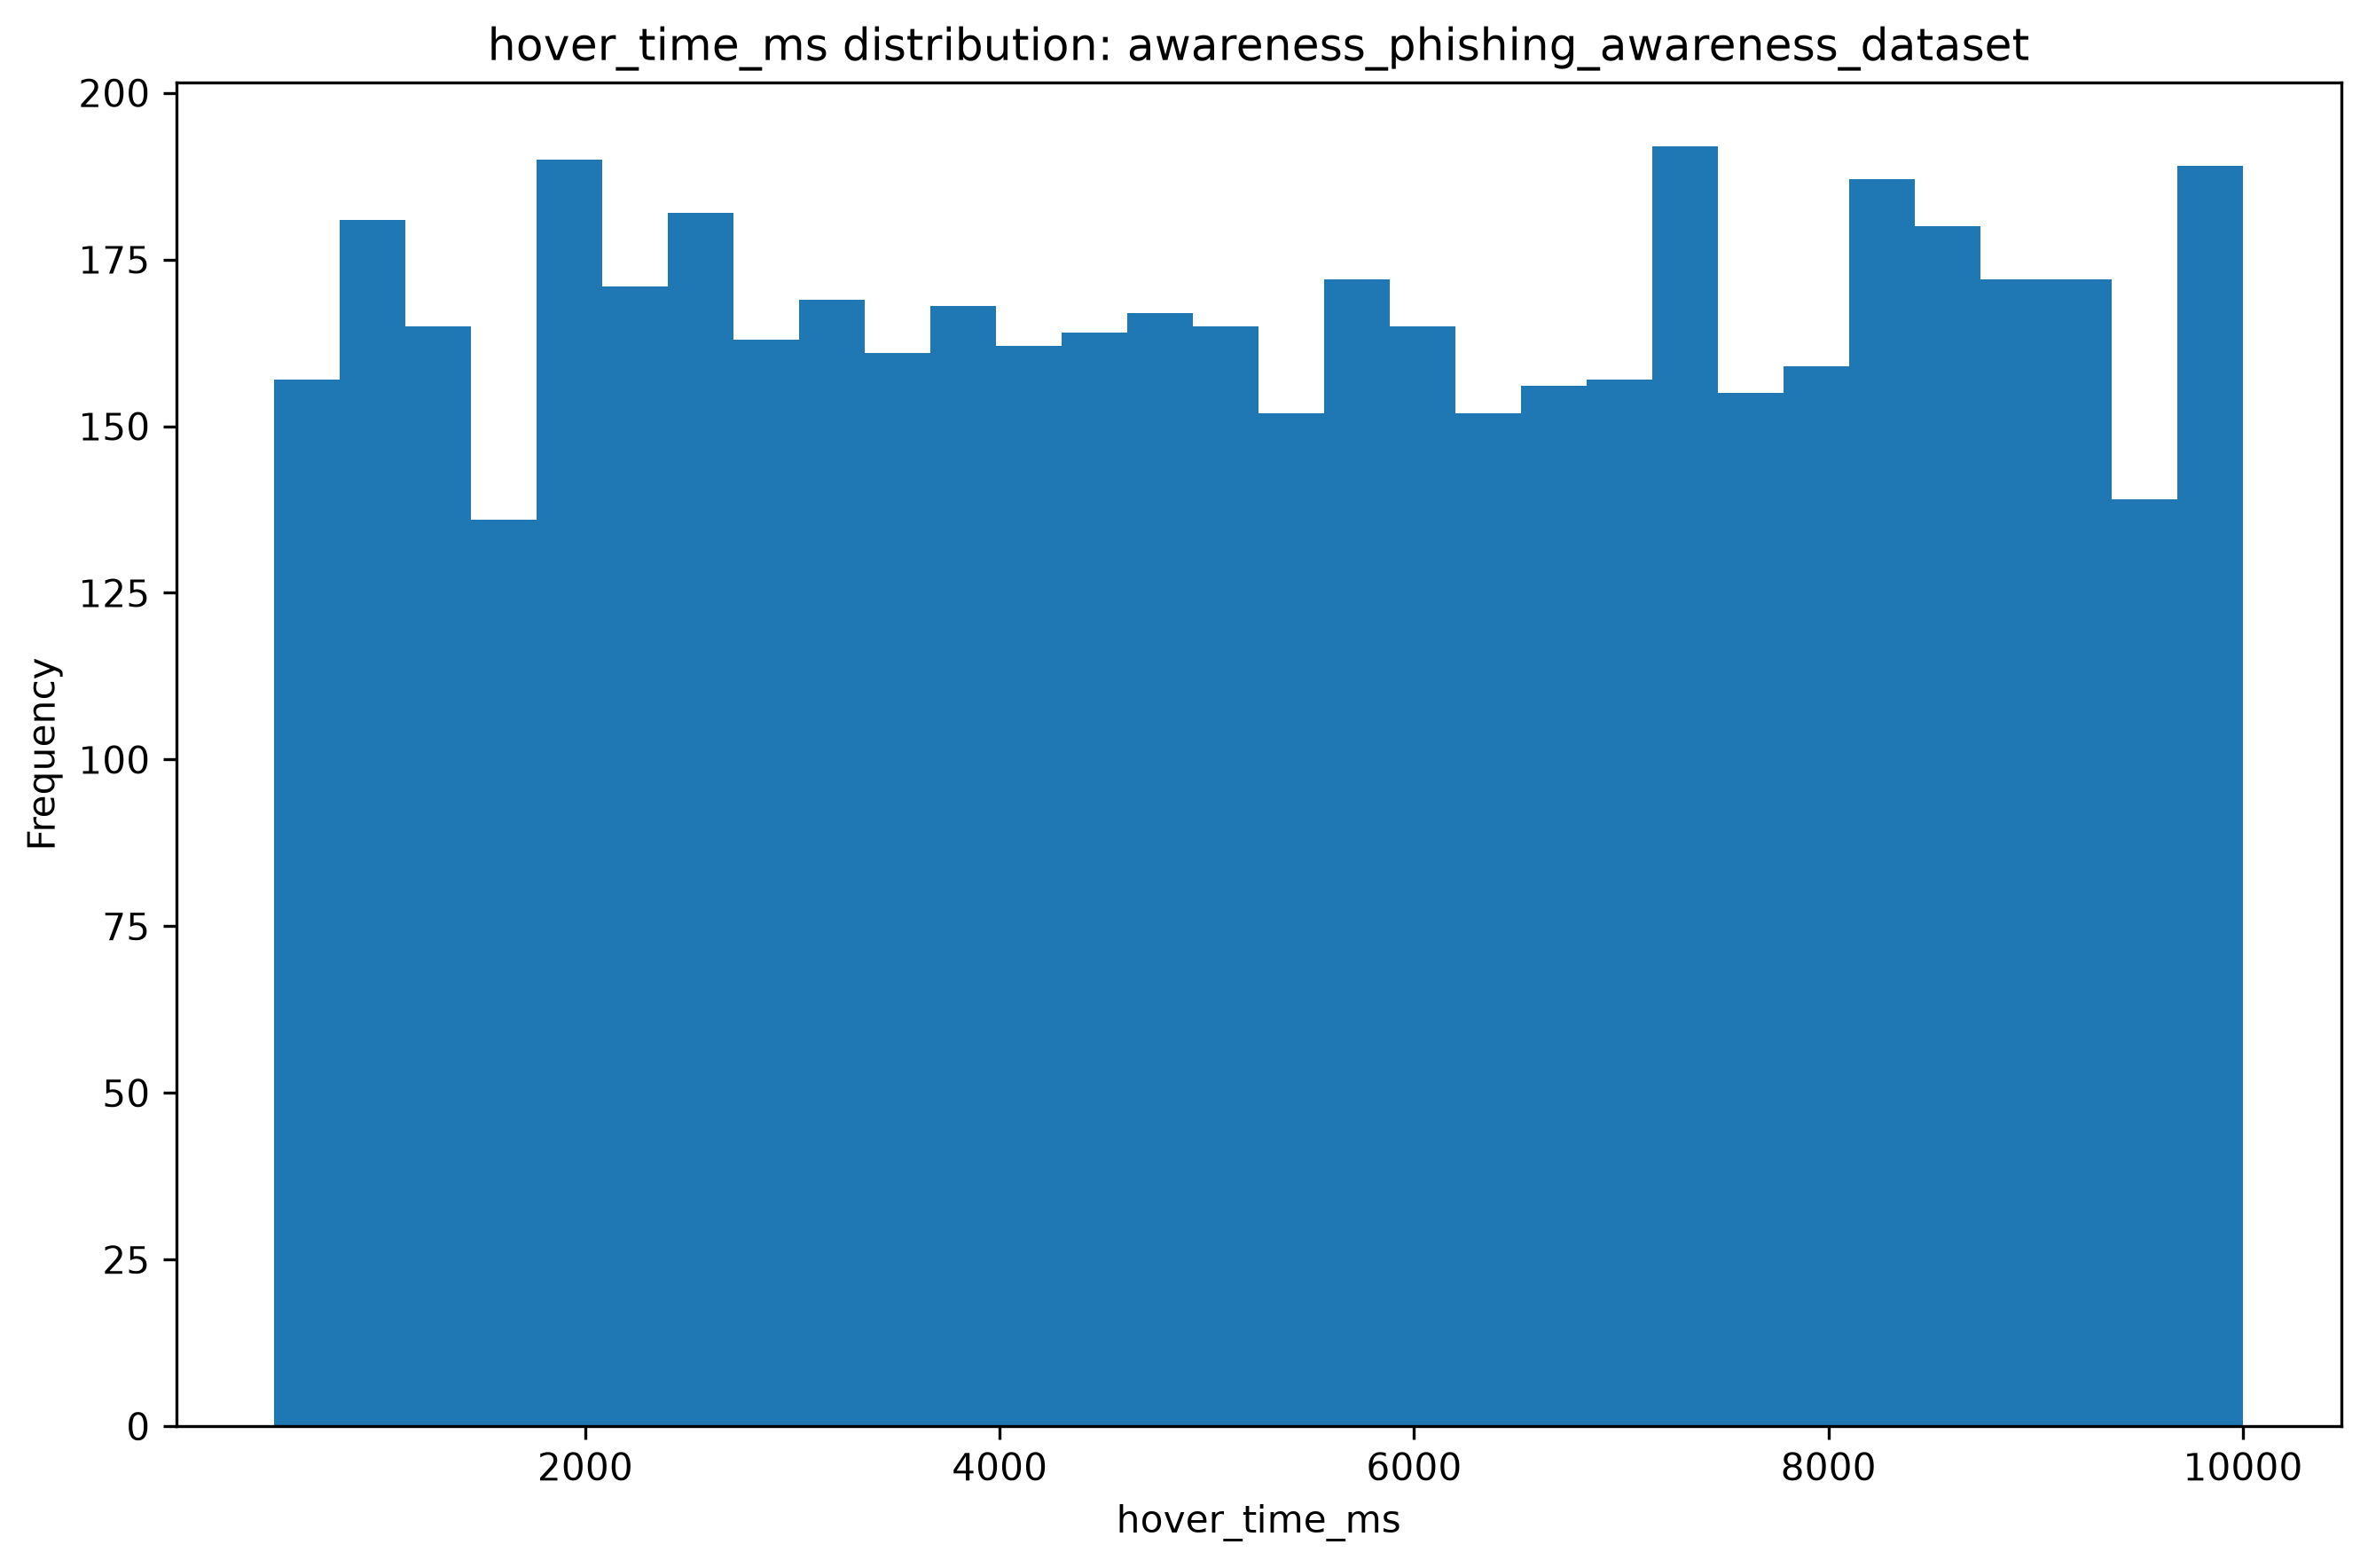

### Awareness Phishing Awareness Dataset Reported Email Categories

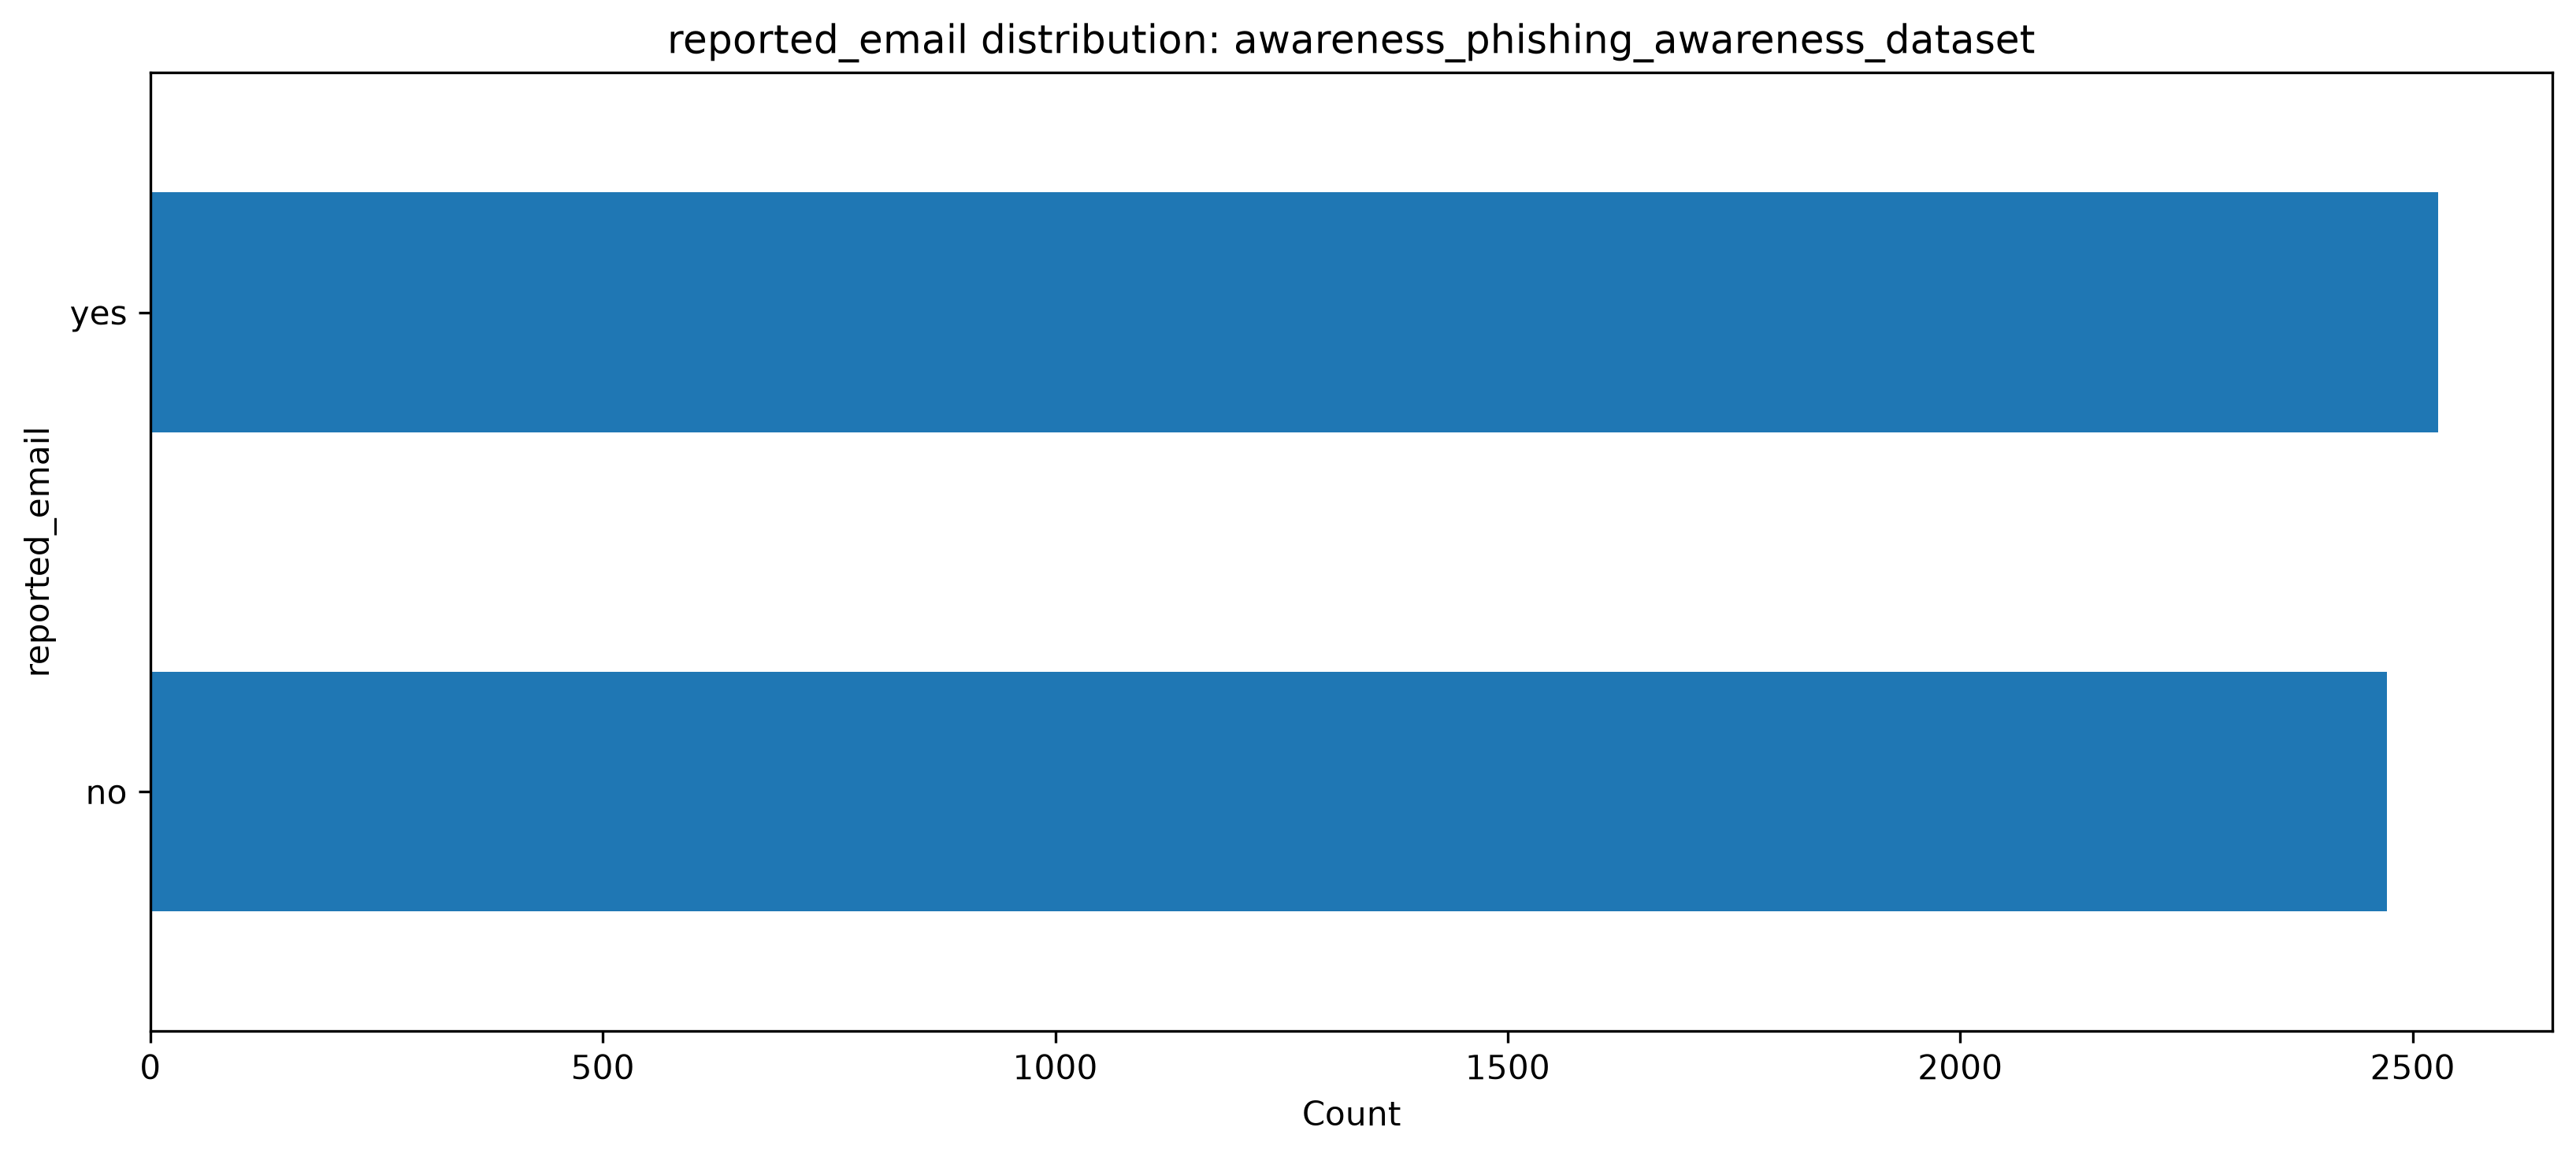

### Awareness Phishing Awareness Dataset Session Duration Sec Histogram

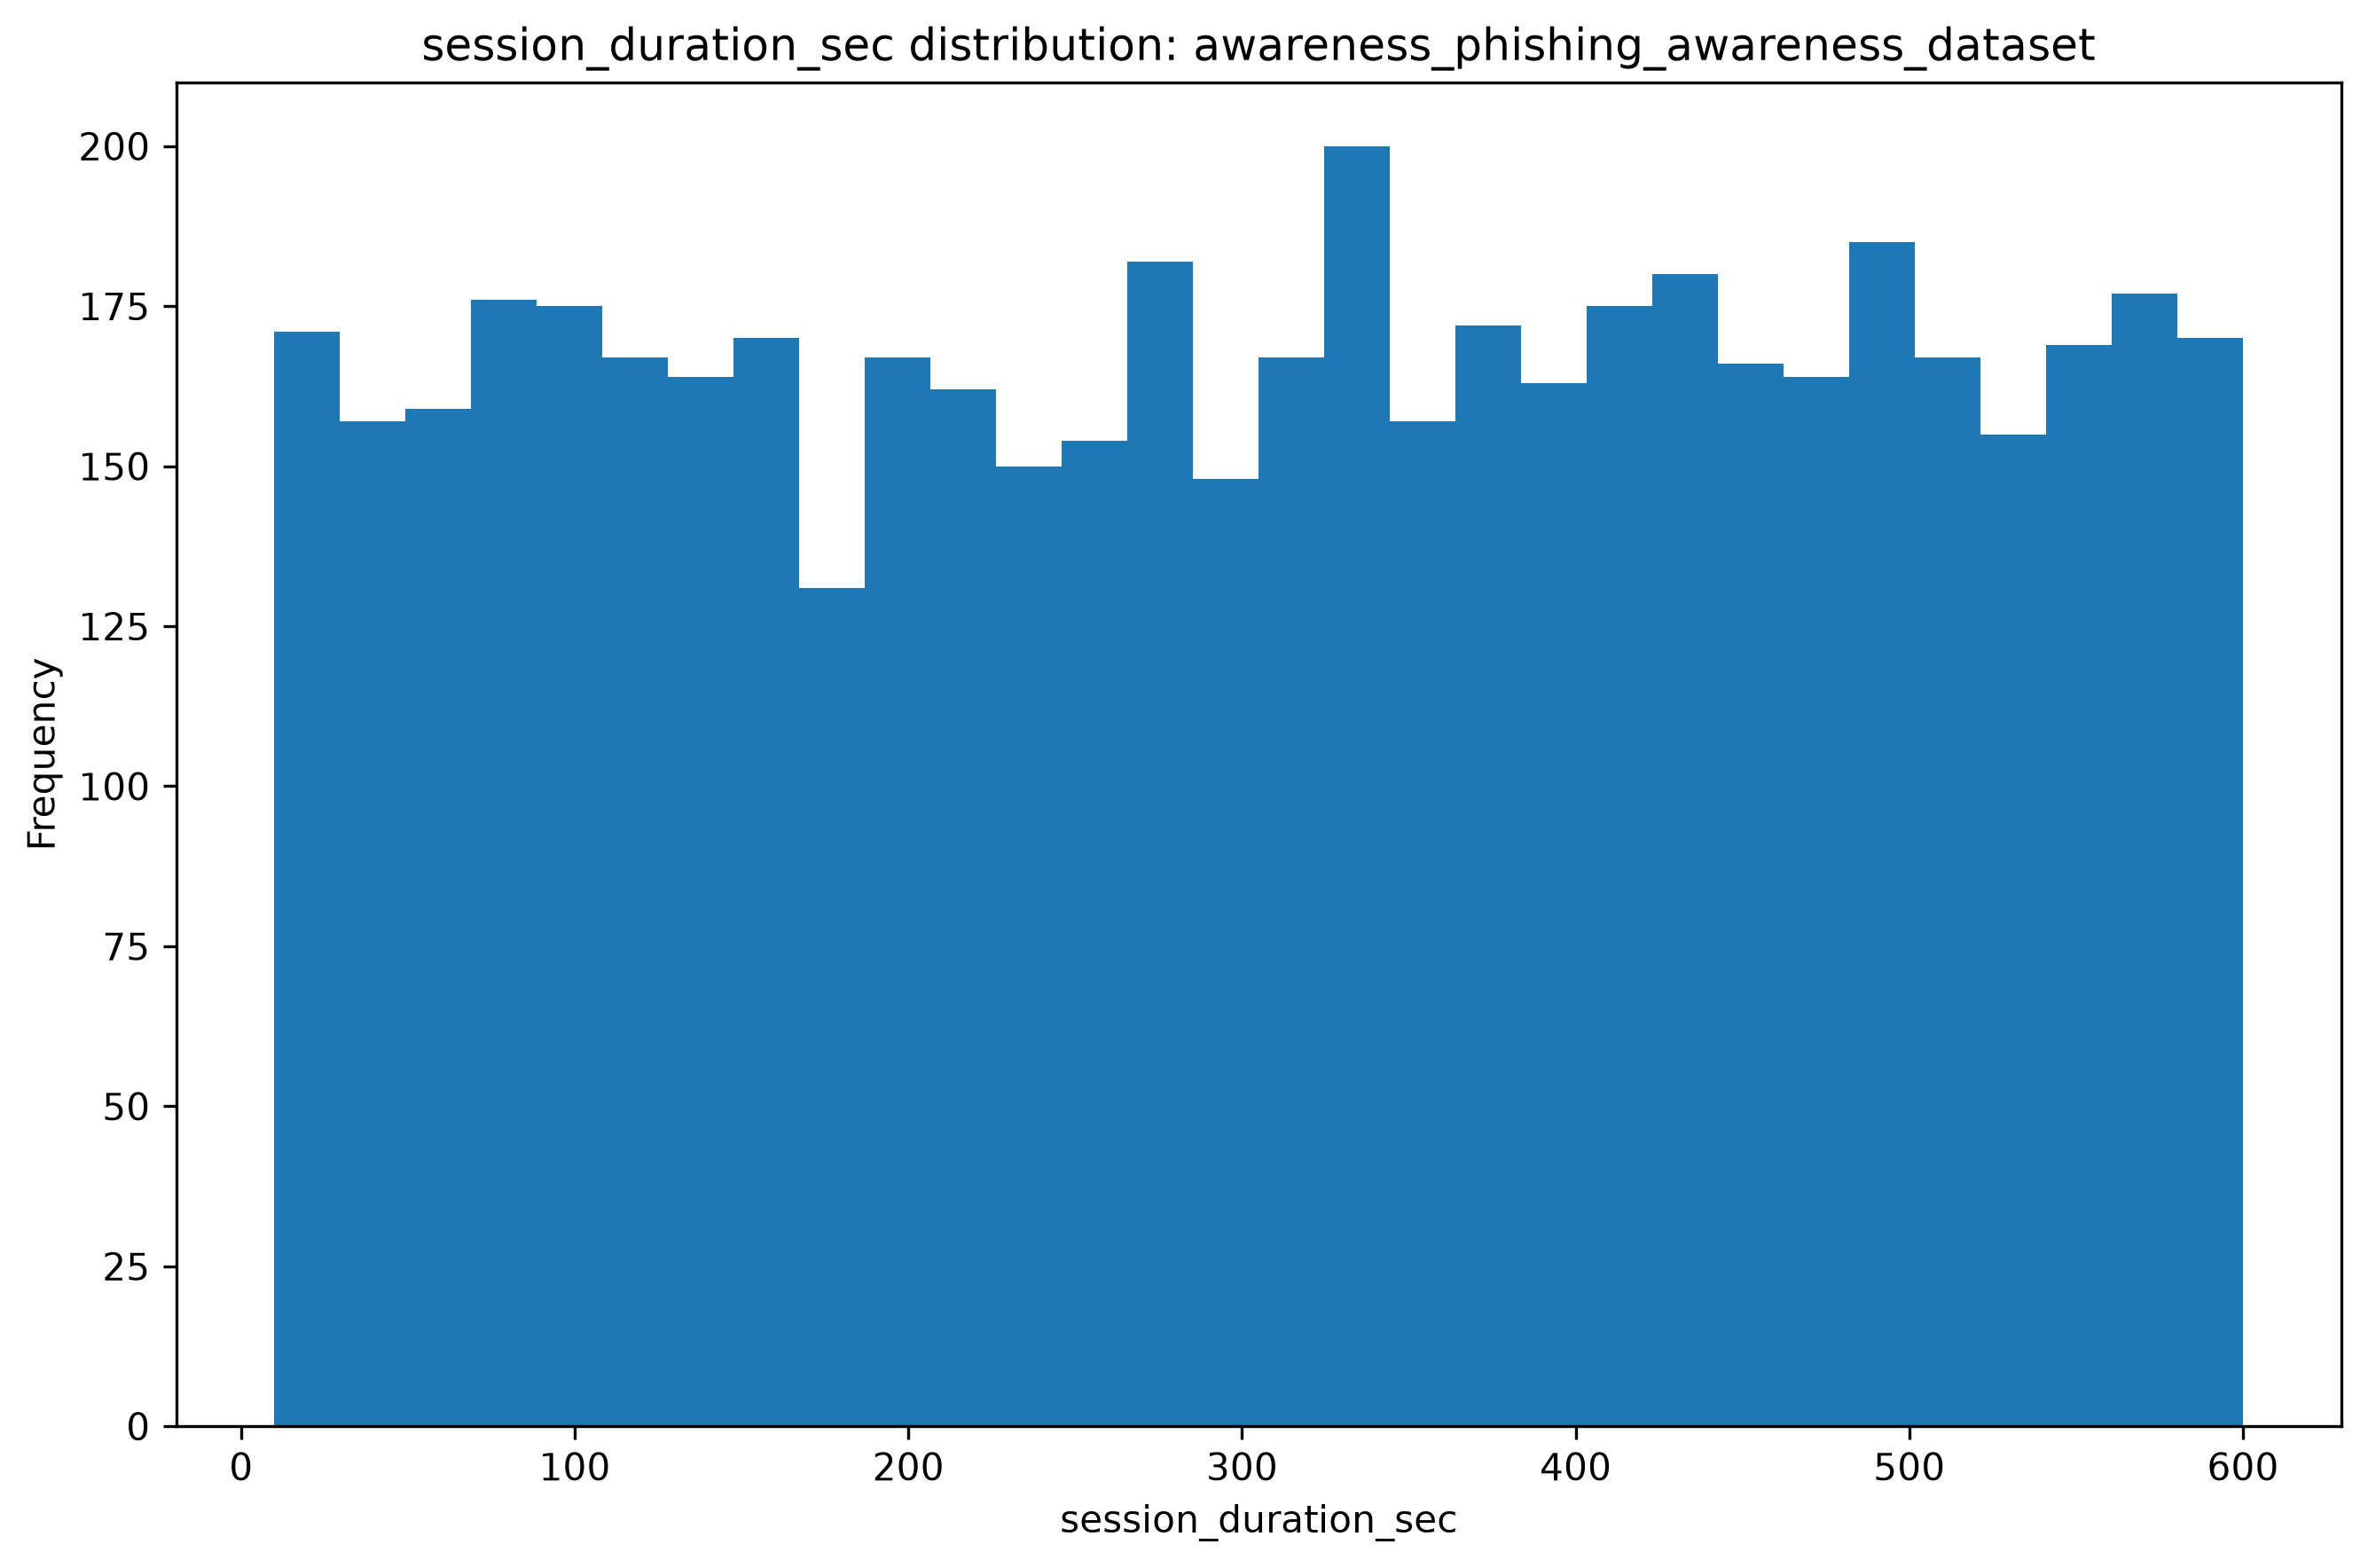

In [23]:
figure_directory = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "eda"
)

awareness_figures = sorted(
    figure_directory.glob(
        "awareness_phishing_awareness_dataset_*.png"
    )
)

print(f"Figures found: {len(awareness_figures)}")

for figure_path in awareness_figures:
    display(
        Markdown(
            f"### {figure_path.stem.replace('_', ' ').title()}"
        )
    )
    display(
        Image(
            filename=str(figure_path)
        )
    )

In [24]:
variable_roles = pd.DataFrame(
    [
        {
            "variable": "user_id",
            "current_role": "Identifier",
            "planned_action": "Exclude from HWI and ML",
            "reason": "Unique identifier with no predictive meaning",
        },
        {
            "variable": "email_subject",
            "current_role": "Text/context feature",
            "planned_action": "Retain for later NLP feature extraction",
            "reason": "May contain urgency, authority or persuasion cues",
        },
        {
            "variable": "sender_email_domain",
            "current_role": "Context feature",
            "planned_action": "Inspect and engineer domain features",
            "reason": "May indicate sender credibility or suspicious patterns",
        },
        {
            "variable": "hover_time_ms",
            "current_role": "Behavioural proxy",
            "planned_action": "Retain",
            "reason": "Measures interaction time before action",
        },
        {
            "variable": "clicked_link",
            "current_role": "Candidate target",
            "planned_action": "Confirm label meaning and use as outcome",
            "reason": "Potential observed susceptibility outcome",
        },
        {
            "variable": "reported_email",
            "current_role": "Security response",
            "planned_action": "Confirm event timing before use",
            "reason": "Could be awareness proxy or post-outcome leakage",
        },
        {
            "variable": "device_type",
            "current_role": "Context feature",
            "planned_action": "Retain provisionally",
            "reason": "Interaction context",
        },
        {
            "variable": "browser_used",
            "current_role": "Context feature",
            "planned_action": "Retain provisionally",
            "reason": "Interaction environment",
        },
        {
            "variable": "email_received_time",
            "current_role": "Timestamp",
            "planned_action": "Derive hour and day variables",
            "reason": "Raw timestamp is not directly model-ready",
        },
        {
            "variable": "session_duration_sec",
            "current_role": "Behavioural proxy",
            "planned_action": "Retain",
            "reason": "Measures interaction duration",
        },
        {
            "variable": "geo_location",
            "current_role": "Sensitive/high-cardinality context",
            "planned_action": "Exclude initially",
            "reason": "Precise coordinates are difficult to justify for HWI",
        },
        {
            "variable": "email_language",
            "current_role": "Context feature",
            "planned_action": "Retain provisionally",
            "reason": "Communication context",
        },
    ]
)

display(variable_roles)

,variable,current_role,planned_action,reason
0,user_id,Identifier,Exclude from HWI and ML,Unique identifier with no predictive meaning
1,email_subject,Text/context feature,Retain for later NLP feature extraction,"May contain urgency, authority or persuasion cues"
2,sender_email_domain,Context feature,Inspect and engineer domain features,May indicate sender credibility or suspicious ...
3,hover_time_ms,Behavioural proxy,Retain,Measures interaction time before action
4,clicked_link,Candidate target,Confirm label meaning and use as outcome,Potential observed susceptibility outcome
5,reported_email,Security response,Confirm event timing before use,Could be awareness proxy or post-outcome leakage
6,device_type,Context feature,Retain provisionally,Interaction context
7,browser_used,Context feature,Retain provisionally,Interaction environment
8,email_received_time,Timestamp,Derive hour and day variables,Raw timestamp is not directly model-ready
9,session_duration_sec,Behavioural proxy,Retain,Measures interaction duration
